<a href="https://colab.research.google.com/github/geriiy/PCVK_Ganjil_2025/blob/main/Week6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as Im

def convolution2d(image, kernel, stride, padding):
  img = cv.imread('/content/drive/MyDrive/PCVK/Lenna.png')
  img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
  kernel_sharpen = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]])
  img_sharpen = convolution2d(img, kernel_sharpen, 1, 2)

# PERCOBAAN 1

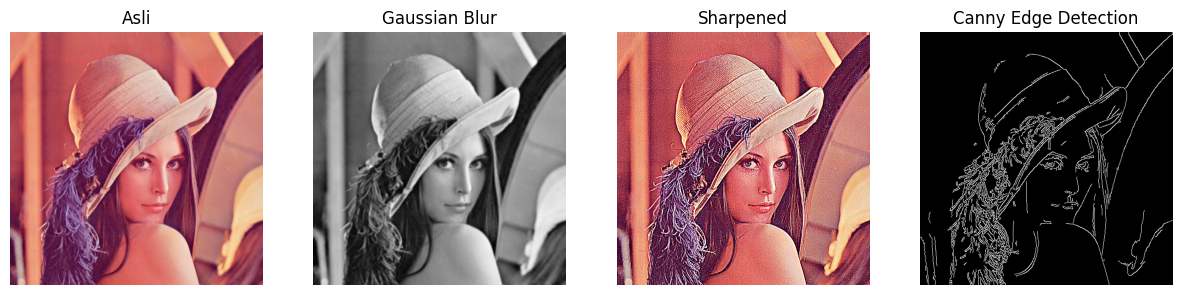

In [8]:
# Fungsi tampil berdampingan
def show_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, img in enumerate(zip(images, titles)):
        if len(img[0].shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img[0], cmap='gray')
        else:
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img[0], cv.COLOR_BGR2RGB))
        plt.title(img[1])
        plt.axis('off')
    plt.show()

img = cv.imread("/content/drive/MyDrive/PCVK/Lenna.png")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

gaussian_blur = cv.GaussianBlur(img_gray, (7,7), 1)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[-1,-1,-1], [-1,9,-1], [-1,-1,-1]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side([img, gaussian_blur, sharpened, edges],
          ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

# PERCOBAAN 2

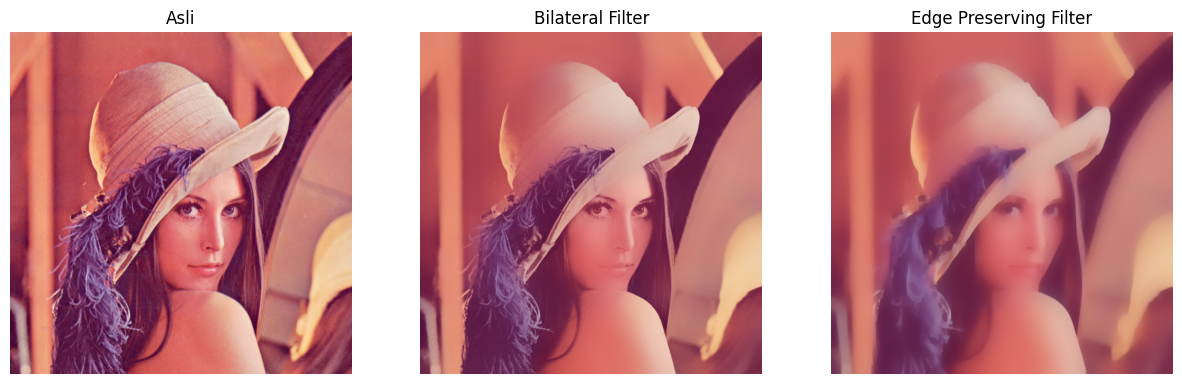

In [10]:
# Filter Modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif Guided Filter)
edge_preserve = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side([img, bilateral, edge_preserve],
          ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

# PERCOBAAN 3

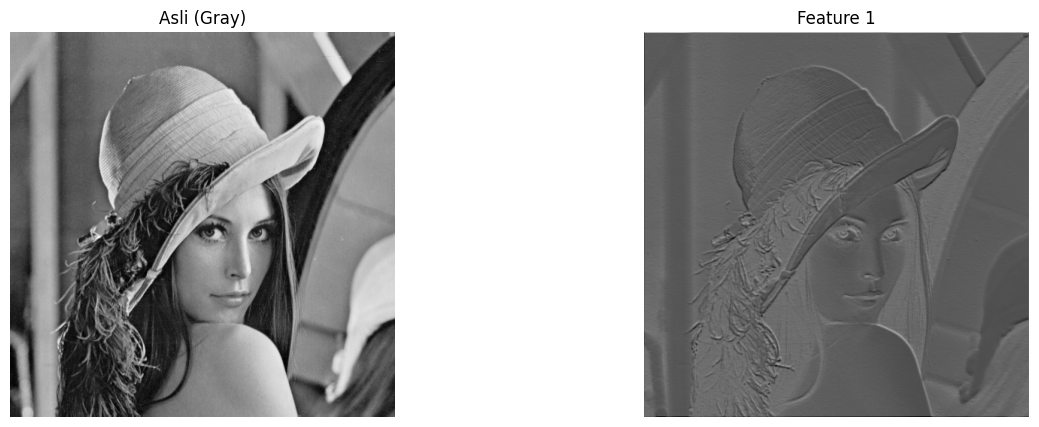

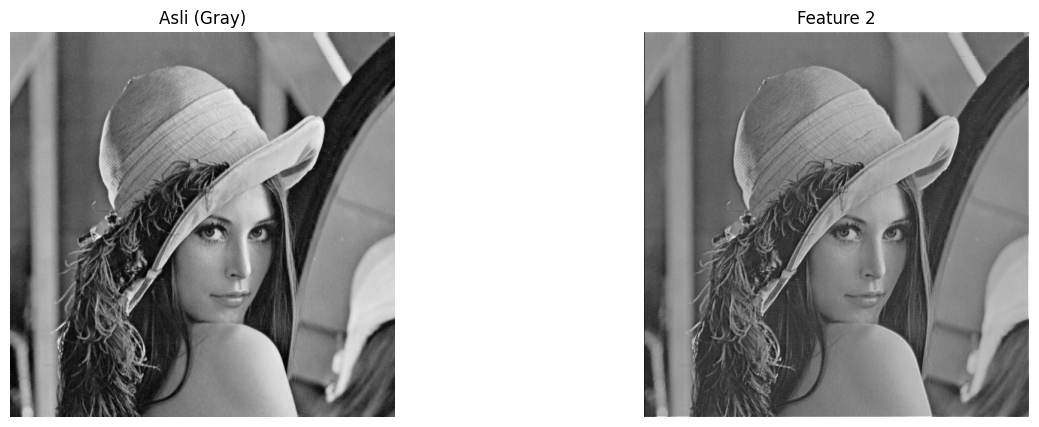

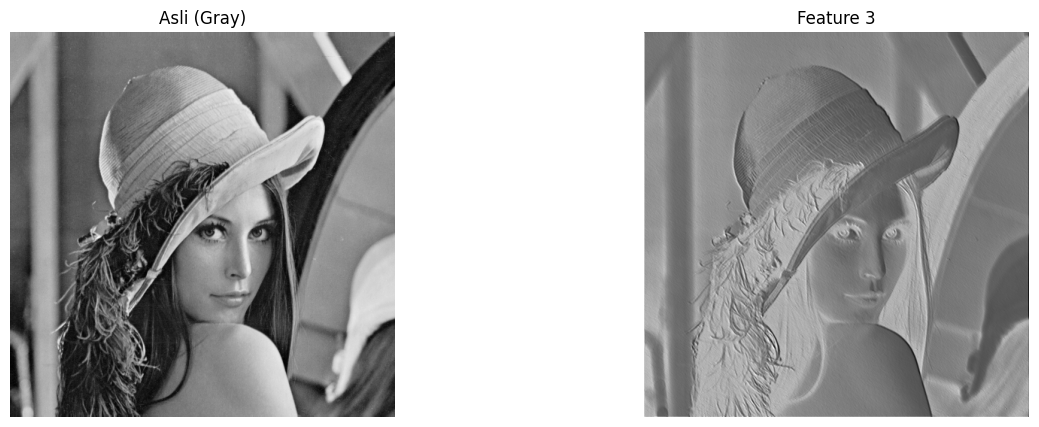

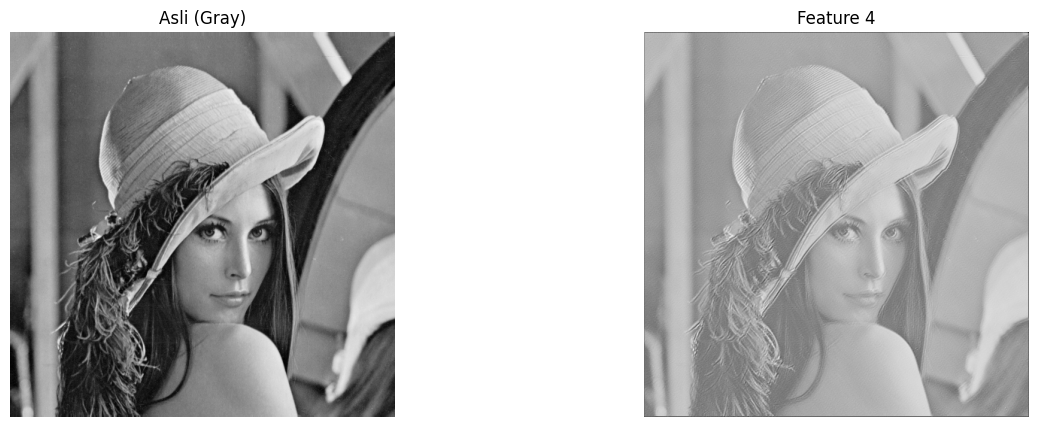

In [12]:
# Filter Feature Map yang digunakan pada CNN, Lakukan running code bagian ini beberapa kali dan perhatikan hasilnya
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        return self.conv(x)

model = SimpleCNN()

# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)

# Visualisasi feature maps
feature_maps = features[0].numpy()
for i in range(features.shape[1]):
    show_side([img_gray, feature_maps[i]],
              [f"Asli (Gray)", f"Feature {i+1}"])

# PERCOBAAN 4

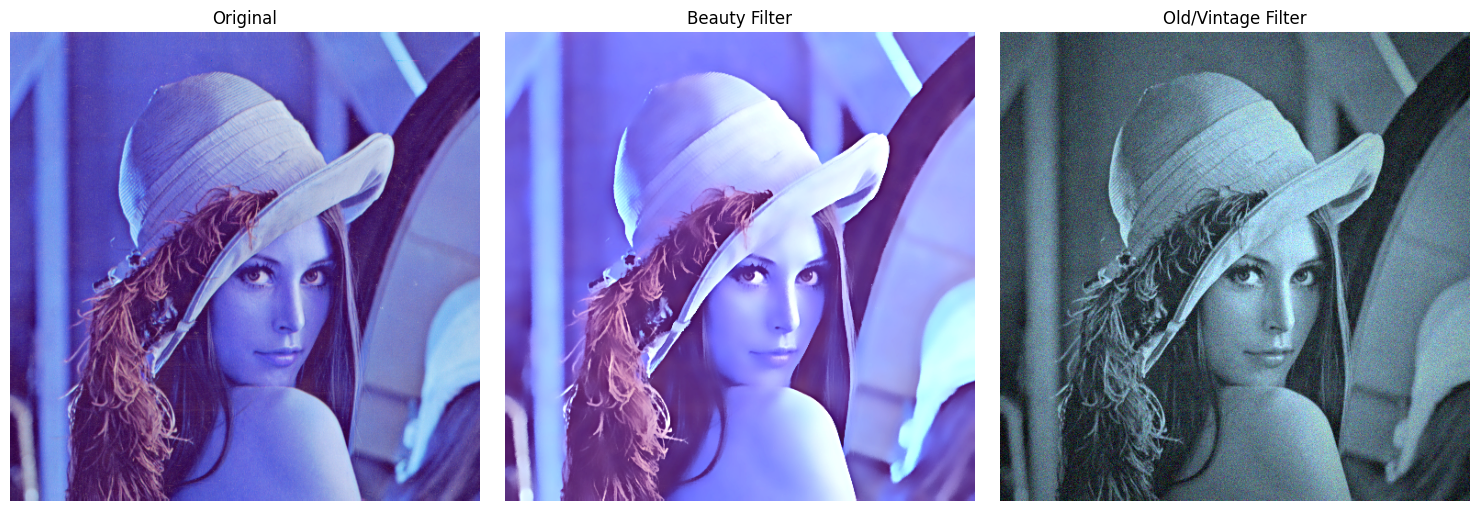

In [15]:
# ====================
# 1. Beauty Filter
# ====================

# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(smooth, (0,0), 3)
sharpened = cv.addWeighted(smooth, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness & contrast
alpha = 1.2  # contrast
beta = 15    # brightness
beauty = cv.convertScaleAbs(sharpened, alpha=alpha, beta=beta)

# ====================
# 2. Old/Vintage Filter
# ====================

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)\

# --- Tampilkan hasil ---
plt.figure(figsize=(15,5))
plt.subplot(1,3,1); plt.imshow(img); plt.title('Original'); plt.axis('off')
plt.subplot(1,3,2); plt.imshow(beauty); plt.title('Beauty Filter'); plt.axis('off')
plt.subplot(1,3,3); plt.imshow(old_img); plt.title('Old/Vintage Filter'); plt.axis('off')
plt.tight_layout()
plt.show()


# PERCOBAAN 5

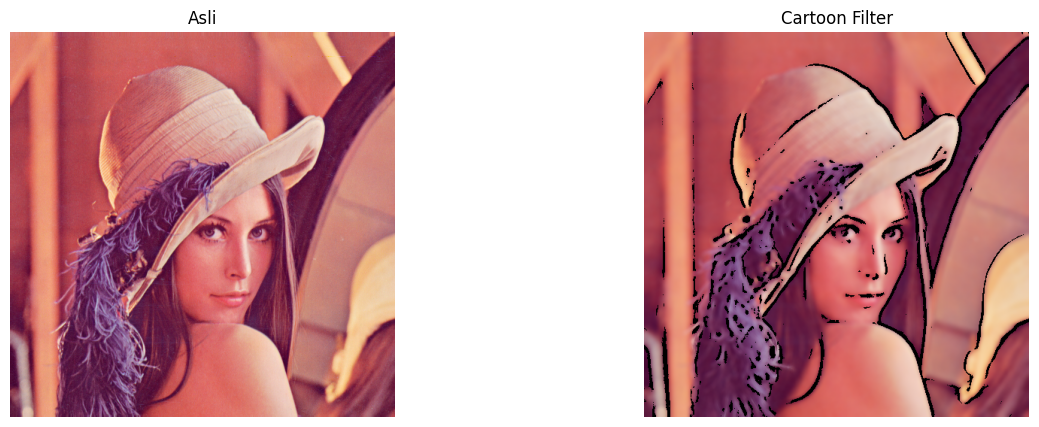

In [16]:
# Filter Anime / Cartoon

# Step 1: Edge detection (pakai median blur dulu agar gambar menjadi lebih halus)
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255,
                             cv.ADAPTIVE_THRESH_MEAN_C,
                             cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan (cartoonize)
cartoon = cv.bitwise_and(color, color, mask=edges)

# Tampilkan
show_side([img, cartoon], ["Asli", "Cartoon Filter"])


# PERCOBAAN 6

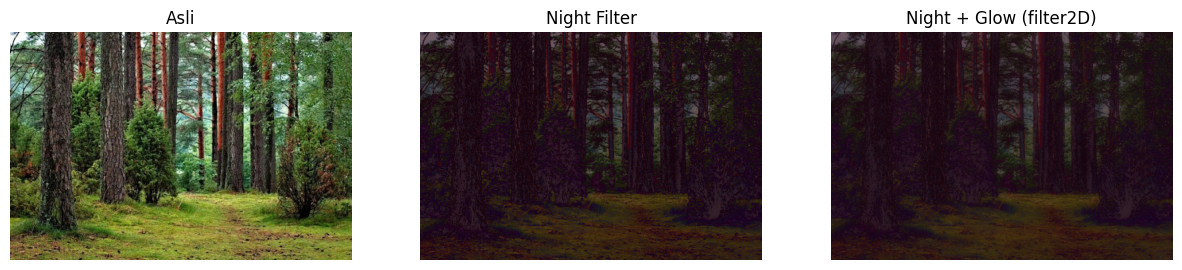

In [17]:
# Night Filter
img = cv.imread("/content/drive/MyDrive/PCVK/hutan.jpg")
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(img, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100))  # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15, 15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side([img, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])


# PERCOBAAN 7

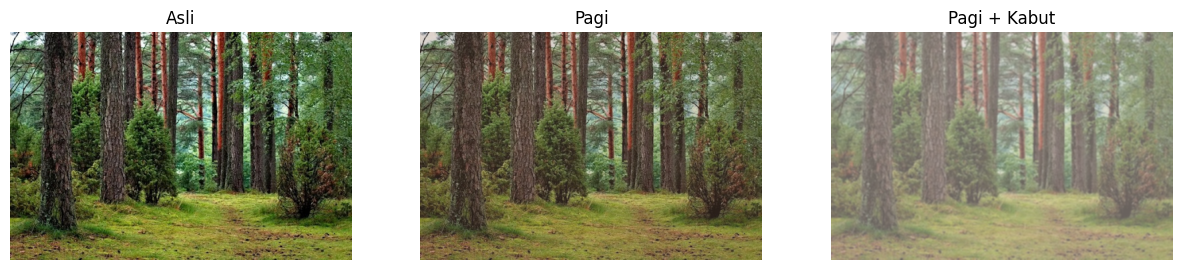

In [18]:
# Filter Suasana pagi dan Kabut
# =============================
# Step 1: Kurangi kontras & cerahkan
# =============================
alpha = 0.9   # contrast
beta = 20     # brightness
soft = cv.convertScaleAbs(img, alpha=alpha, beta=beta)


# =============================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# =============================
warm_tint = np.full_like(soft, (40, 70, 120))  # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)


# =============================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# =============================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T   # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side([img, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])
